In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import contacts,distances
import io
from PIL import Image
from collections import defaultdict
import itertools
import pickle
import seaborn as sns
import glob
import matplotlib.ticker as ticker

/Users/adelielouet/miniforge3/envs/msm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

xtc = '/Users/adelielouet/Documents/science/AB_G5_original_simu_analysis/trajectories/Gabis_paper/traj_all-skip-0-noW_G5.xtc'
pdb = '/Users/adelielouet/Documents/science/AB_G5_original_simu_analysis/trajectories/Gabis_paper/template_G5.pdb'

abeta="A\u03B2-42"
alpha_syn_c="\u03B1-syn-C-term"
alpha_full_length="\u03B1-syn-full"

protein_name=abeta

In [3]:
def contacts_within_cutoff(u, group_a, group_b, radius=3.0):
    timeseries = []
    for ts in u.trajectory:
        dist = contacts.distance_array(group_a.positions, group_b.positions)
        n_contacts = contacts.contact_matrix(dist, radius).sum()
        timeseries.append([n_contacts])
    return np.array(timeseries)

## Time series of the binding of G5 to Aβ42 

The x-axis shows the simulation time steps, and the y-axis indicates whether G5 is in contact with each residue of Aβ42

/var/folders/y3/sm2gn5053mz_rtfqrj0r8mz40000gn/T/ipykernel_54141/71072741.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ca_df = ca_df.applymap(lambda x: 1 if x > 0 else x)
/var/folders/y3/sm2gn5053mz_rtfqrj0r8mz40000gn/T/ipykernel_54141/71072741.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ca_df = ca_df.applymap(lambda x: 1 if x > 0 else x)


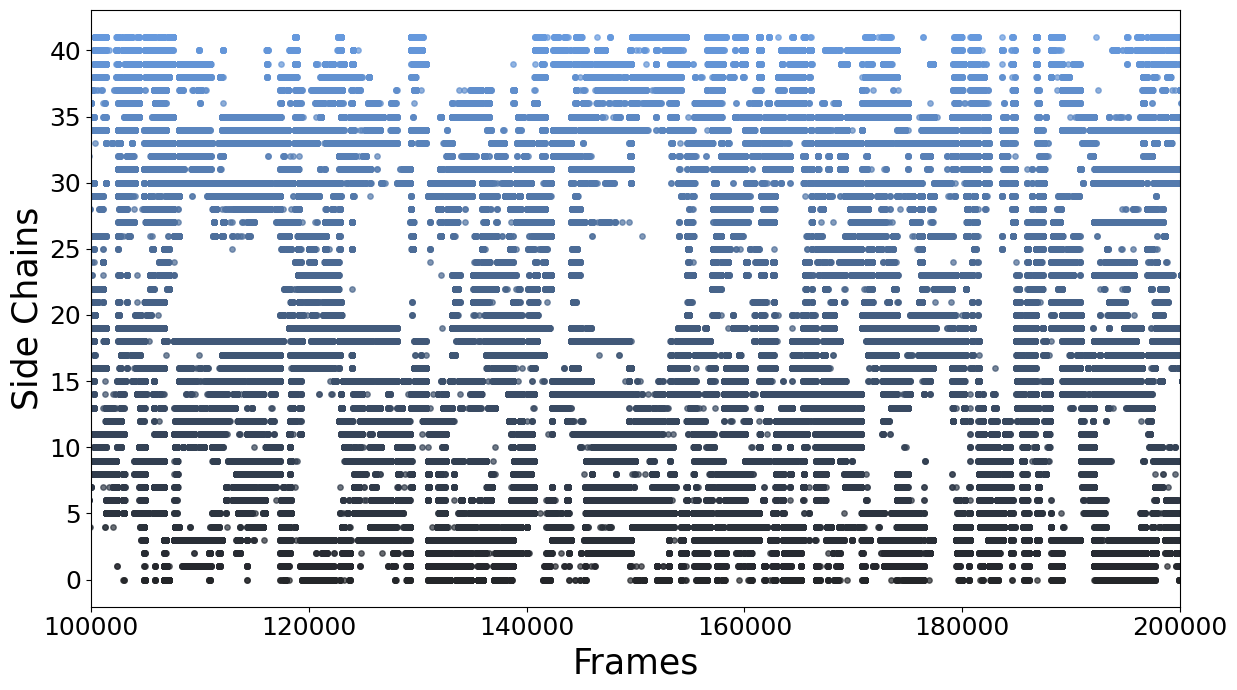

In [4]:

u = mda.Universe(pdb, xtc)

resid_list = ['resid ' + str(i) for i in range(1, len(u.residues))]

ca_df = pd.DataFrame(index=range(len(u.trajectory)))

for y in resid_list:
    #ligand = u.select_atoms('resname liga')
    ligand=u.select_atoms('resid 43')
    pocket = u.select_atoms(y)
    ca = contacts_within_cutoff(u, ligand, pocket, radius=3.0)
    ca_df[y] = ca.flatten()

ca_df.rename(columns={x: y for x, y in zip(ca_df.columns, range(0, len(ca_df.columns)))}, inplace=True)

new_column_names = [f"Aromatic Residue {i}" for i in range(0, 5)]
if len(new_column_names) == len(ca_df.columns):
    ca_df.columns = new_column_names

ca_df = ca_df.applymap(lambda x: 1 if x > 0 else x)
ca_df = ca_df.replace(0, np.nan)

ca_df.rename(columns={x:y for x,y in zip(ca_df.columns,range(0,len(ca_df.columns)))})


new_column_names = [f"Residue {i}" for i in range(1, 43)]
if len(new_column_names) == len(ca_df.columns):
    ca_df.columns = new_column_names

ca_df = ca_df.applymap(lambda x: 1 if x > 0 else x)
ca_df = ca_df.replace(0, np.nan)

palette = sns.dark_palette("#69d", n_colors=len(ca_df.columns))


plt.figure(figsize=(12, 7))  

save_feat=[]
for i, (col, color) in enumerate(zip(ca_df.columns, palette)):
    y = [i if not pd.isnull(ca_df[col][j]) else None for j in range(len(ca_df))]
    x = list(range(len(ca_df)))
    resn = col.split(' ')[-1]
    save_feat.append([x,y])
    plt.scatter(x, y, s=15, color=color, alpha=0.7)  # Increased size, added transparency

#plt.yticks(range(len(ca_df.columns)), range(0,len(ca_df.columns)))
tick_positions = list(range(0, len(ca_df.columns), 5))  # every other tick
tick_labels = tick_positions  # could also use custom labels if needed
plt.yticks(tick_positions, tick_labels, fontsize=18)
plt.xticks(fontsize=18)

plt.xlabel('Frames', fontsize=25,y=-0.05)
plt.ylabel('Side Chains', fontsize=25,x=-0.05)
#plt.title(f'{protein_name} Side Chains Retention Time', fontsize=16)
#plt.grid(color='blue', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()

plt.xlim(100000, 200000)  # Zoom into the desired time range
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/abeta_time_retention_zoomed.png', dpi=300)

plt.show()


## Handoff matrices for the binding of G5 to Aβ42

(a) Case A: A handoff occurs from residue i to residue j, regardless of whether residue i maintains its interaction with the ligand. (b) Case B: Residue i loses contact with the ligand while residue j gains contact, representing a true handoff. (c) Case C: Residue i retains its interaction, and residue j forms a new contact, indicating an additional interaction rather than a replacement.



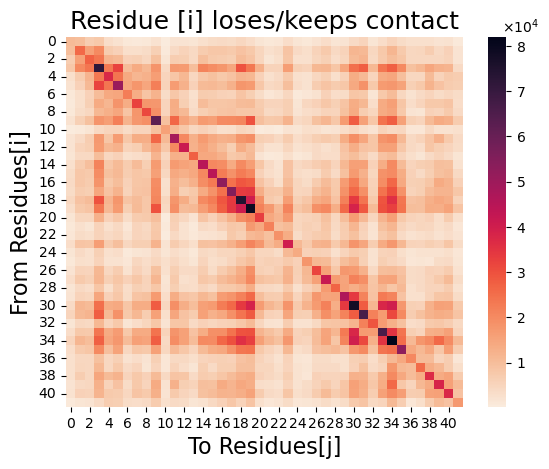

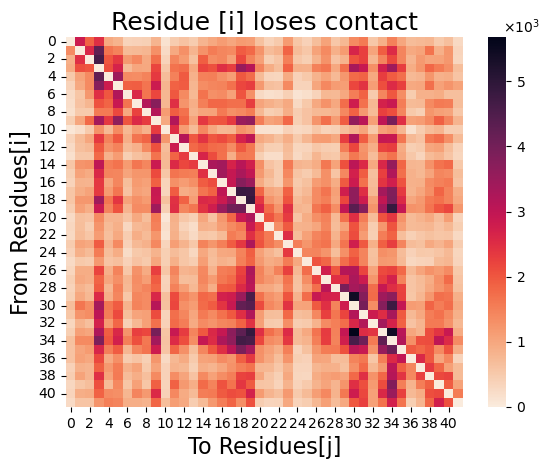

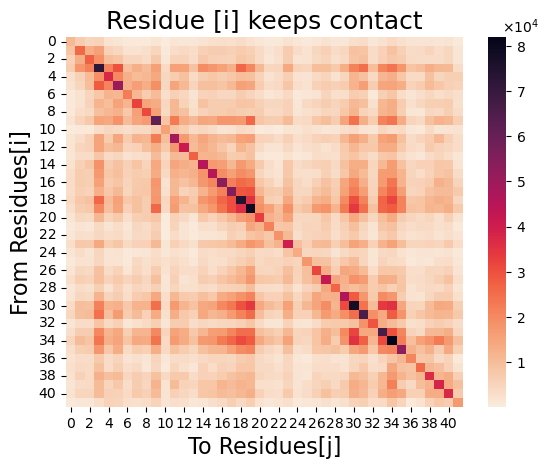

In [5]:

########## SNS Heatmap #######################
#1. Case A - handoff between contact[i] --> contact[j], irrespective of whether or not contact[i] loses its contact
ca_df = ca_df.replace(np.nan,0)
ca_df_mat=ca_df.to_numpy()

ligand = u.select_atoms('not protein')
protein = u.select_atoms('protein')

sequence=ca_df_mat
residues = ((list(atom.resname for atom in protein.residues)))
num_residues = len(residues)

transition_matrix = np.zeros((num_residues, num_residues))

for step in range(len(sequence) - 1):
    current_contact = sequence[step]
    next_contact = sequence[step + 1]

    for i, residue_i in enumerate(residues):
        for j, residue_j in enumerate(residues):
            if current_contact[i] == 1 and next_contact[j] == 1:
                transition_matrix[i][j] += 1


ax = sns.heatmap(transition_matrix, cmap='rocket_r')
colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
colorbar.ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
colorbar.ax.yaxis.offsetText.set_x(2.8)
#plt.suptitle(f'{protein_name} Matrix Residues-contact handoff [i] --> [j]', size=16, y=1.0)
plt.title('Residue [i] loses/keeps contact',size=18) #,style='italic' )
plt.ylabel('From Residues[i]',size=16)
plt.xlabel('To Residues[j]',size=16)
plt.xticks(fontsize=10)
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/matrix_handoff_A.png', dpi=300)
plt.show()

#2. Case B -  handoff between contact[i] --> contact[j] with contact[i] losing its contact
transition_matrix_lose = np.zeros((num_residues, num_residues))

for step in range(len(sequence) - 1):
    current_contact = sequence[step]
    next_contact = sequence[step + 1]

    for i, residue_i in enumerate(residues):
        for j, residue_j in enumerate(residues):
            if current_contact[i] == 1 and next_contact[j] == 1 and next_contact[i] == 0:
                transition_matrix_lose[i][j] += 1

ax = sns.heatmap(transition_matrix_lose, cmap='rocket_r')
colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
colorbar.ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
colorbar.ax.yaxis.offsetText.set_x(2.8)
#sns.heatmap(transition_matrix_lose, cmap='rocket_r')
#plt.suptitle(f'{protein_name} Matrix Residues-contact handoff [i] --> [j]',y=1.0,size=16)
plt.title('Residue [i] loses contact',size=18) #,style='italic' )
plt.ylabel('From Residues[i]',size=16)
plt.xlabel('To Residues[j]',size=16)
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/matrix_handoff_B.png', dpi=300)
plt.show()


# Case C - handoff between contact[i] --> contact[j] with contact[i] keeping its contact

transition_matrix_keep = np.zeros((num_residues, num_residues))

for step in range(len(sequence) - 1):
    current_contact = sequence[step]
    next_contact = sequence[step + 1]

    for i, residue_i in enumerate(residues):
        for j, residue_j in enumerate(residues):
            if current_contact[i] == 1 and next_contact[j] == 1 and next_contact[i] == 1:
                transition_matrix_keep[i][j] += 1


ax = sns.heatmap(transition_matrix_keep, cmap='rocket_r')
colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
colorbar.ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
colorbar.ax.yaxis.offsetText.set_x(2.8)
#sns.heatmap(transition_matrix_keep, cmap='rocket_r')
#plt.suptitle(f'{protein_name} Matrix Residues-contact handoff [i] --> [j]')
plt.title('Residue [i] keeps contact',size=18) #,style='italic' )
plt.ylabel('From Residues[i]',size=16)
plt.xlabel('To Residues[j]',size=16)
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/matrix_handoff_C.png', dpi=300)

plt.show()


